In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# Loading the Dataset
df = pd.read_csv("diabetes.csv")
print(df.shape)
print(df.head())
print(df.columns.tolist())

(768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [16]:
print( df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB
None


In [17]:
print(df.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  121.677083      72.389323      29.089844  141.753906   
std       3.369578   30.464161      12.106039       8.890820   89.100847   
min       0.000000   44.000000      24.000000       7.000000   14.000000   
25%       1.000000   99.750000      64.000000      25.000000  102.500000   
50%       3.000000  117.000000      72.000000      28.000000  102.500000   
75%       6.000000  140.250000      80.000000      32.000000  169.500000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    32.434635                  0.471876   33.240885    0.348958  
std      6.880498                  0.331329   11.760232    0.476951  
min     18.200000                  

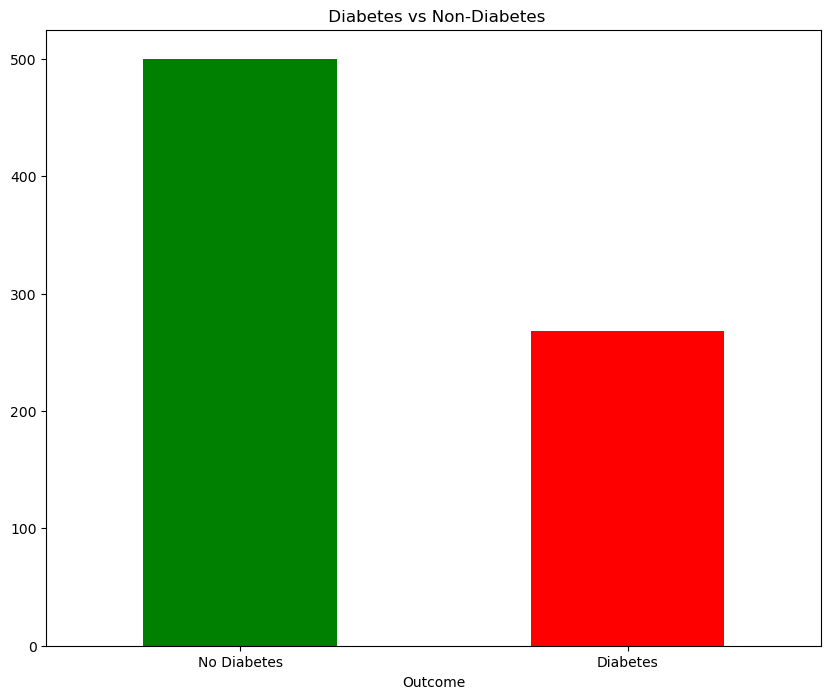

Outcome
0    500
1    268
Name: count, dtype: int64
Diabetes Percentage: 34.9 %


In [25]:
# Outcome Distribution
plt.figure(figsize=(10,8))
df['Outcome'].value_counts().plot(kind='bar',color=['green', 'red'])
plt.title(' Diabetes vs Non-Diabetes')
plt.xticks([0,1], ['No Diabetes', 'Diabetes'], rotation=0)
plt.show()

print(df['Outcome'].value_counts())
print('Diabetes Percentage:', round(df['Outcome'].mean()*100, 2), "%")

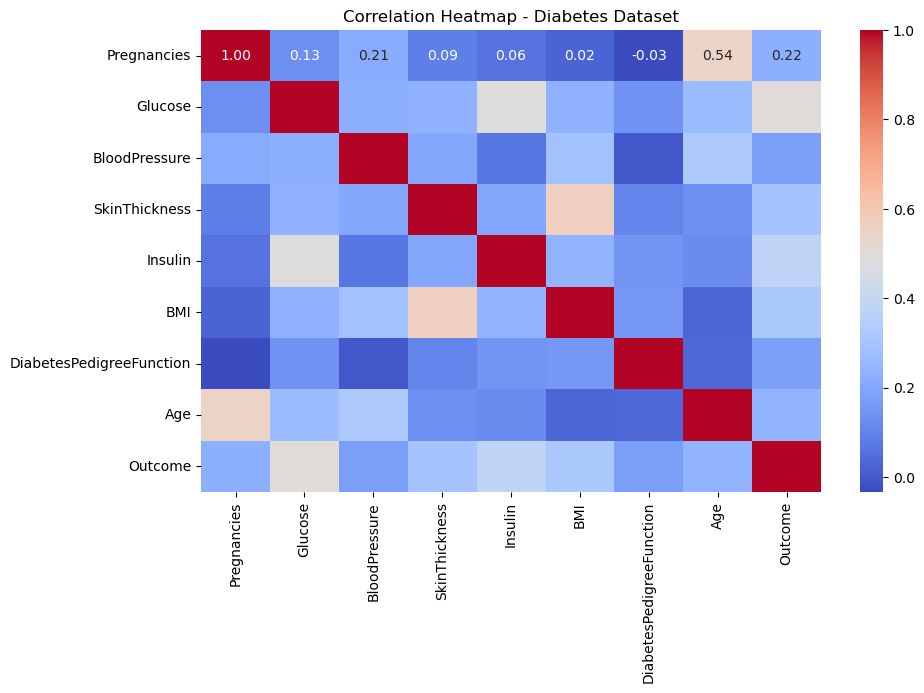

In [31]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Diabetes Dataset')
plt.show()

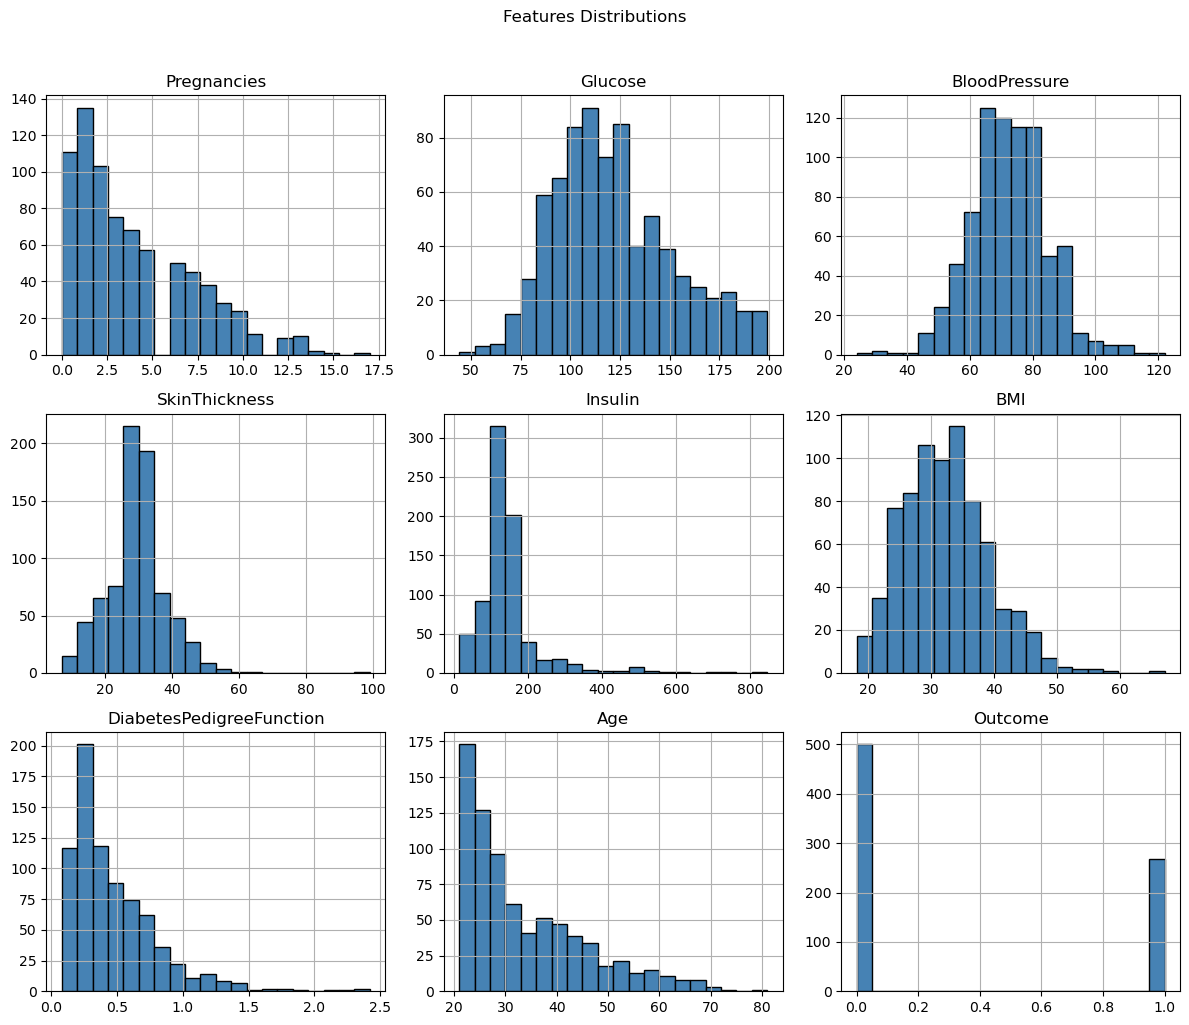

In [29]:
# Distribution of all features
df.hist(figsize=(12,10), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Features Distributions', y=1.02)
plt.tight_layout()
plt.show()

In [33]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df.drop('Outcome', axis=1).values
y = df['Outcome'].values

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print('Train Shape', X_train.shape)
print('Test shape', X_test.shape)

Train Shape (614, 8)
Test shape (154, 8)


In [37]:
# Logistic Regression from Scratch

# Step 1: Sigmoid Function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Testing
print(sigmoid(0)) # should be 0.5
print(sigmoid(100)) # should be close to 1
print(sigmoid(-100)) # should be close to 0

0.5
1.0
3.7200759760208356e-44


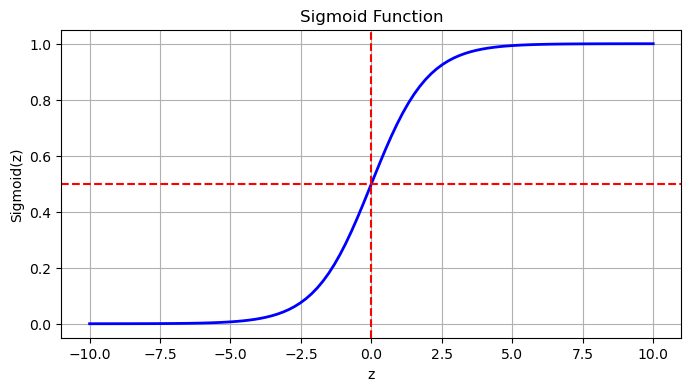

In [39]:
# Visualzing Sigmoid Curve
z = np.linspace(-10, 10, 100)
plt.figure(figsize=(8,4))
plt.plot(z, sigmoid(z), color='blue', linewidth=2)
plt.axhline(y=0.5, color= 'red', linestyle='--')
plt.axvline(x=0, color= 'red', linestyle='--')
plt.title('Sigmoid Function')
plt.xlabel('z')
plt.ylabel('Sigmoid(z)')
plt.grid(True)
plt.show()

In [41]:
# Step 2: Cost function (Log loss)
def compute_cost(X, y, w, b):
    m = len(y) # No.of Training examples

    # Calculating Predictions
    z = np.dot(X, w) + b
    predictions = sigmoid(z)

    # Calculating Log loss
    cost = -1 / m * np.sum(y * np.log(predictions) + (1 - y) * np.log(1 - predictions))
    return cost

In [42]:
# Step 3: Gradient Descent
def gradient_descent(X, y, learning_rate=0.01, iterations=1000):
    m, n = X.shape # m = samples, n = features
    w = np.zeros(n) # start with all weights = 0
    b = 0

    cost_history = [] # Tracing cost over time

    for i in range(iterations):
        # Forward Pass - make predictions
        z = np.dot(X, w) + b
        predictions = sigmoid(z)

        # Calculate gradients
        dw = 1 / m * np.dot(X.T, (predictions - y))
        db = 1 / m * np.sum(predictions - y)

        # Update w & b
        w = w - learning_rate * dw
        b = b - learning_rate * db

        # Store cost every 100 iterations
        if i % 100 == 0:
            cost = compute_cost(X, y, w, b)
            cost_history.append(cost)
            print(f"Iteration {i}: Cost: {cost: .4f}")

    return w, b, cost_history

In [43]:
# Step 4: Predict function
def predict(X, w, b):
    z= np.dot(X, w) + b
    predictions = sigmoid(z)
    # Convert probability to 0 or 1
    return (predictions >= 0.5).astype(int)

In [44]:
# Step 5: Training the model
w, b, cost_history = gradient_descent(
    X_train, y_train, learning_rate=0.01, iterations=1000
)

Iteration 0: Cost:  0.6912
Iteration 100: Cost:  0.5694
Iteration 200: Cost:  0.5202
Iteration 300: Cost:  0.4953
Iteration 400: Cost:  0.4808
Iteration 500: Cost:  0.4715
Iteration 600: Cost:  0.4652
Iteration 700: Cost:  0.4608
Iteration 800: Cost:  0.4576
Iteration 900: Cost:  0.4552


In [46]:
# Step 6 - Evaluate our scratch model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions
y_pred_scratch = predict(X_test, w, b)

# Accuracy
accuracy = accuracy_score(y_test, y_pred_scratch)
print(f"From Scratch Accuracy: {accuracy*100:.2f}%")

From Scratch Accuracy: 79.87%


In [47]:
# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_scratch))


Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.92      0.86       100
           1       0.79      0.57      0.67        54

    accuracy                           0.80       154
   macro avg       0.80      0.75      0.76       154
weighted avg       0.80      0.80      0.79       154



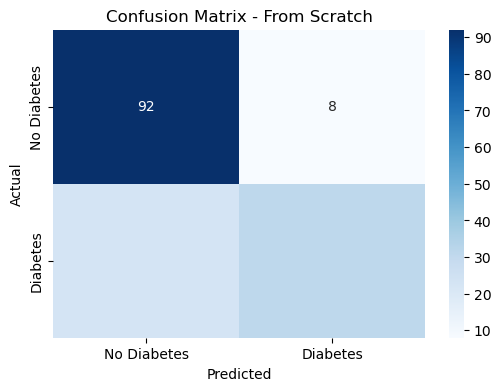

In [48]:
# Confusion matrix
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, y_pred_scratch)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix - From Scratch')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

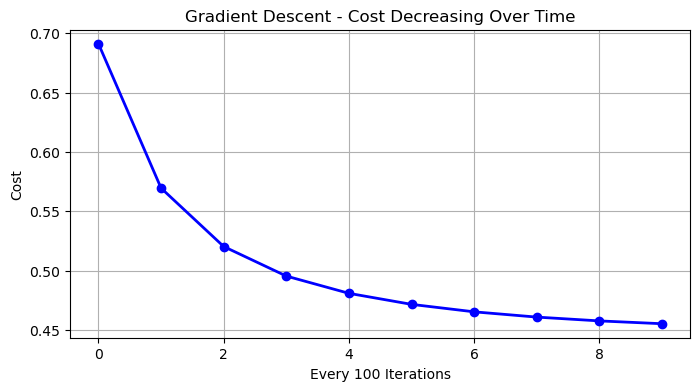

In [52]:
# Plot cost decreasing over time
plt.figure(figsize=(8,4))
plt.plot(cost_history, color='blue', linewidth=2, marker='o')
plt.title('Gradient Descent - Cost Decreasing Over Time')
plt.xlabel('Every 100 Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

In [50]:
# Comparing with sklearn
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=23)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
print(f"From Scratch Accuracy: {accuracy*100:.2f}%")
print(f"From sklearn model Accuracy: {lr_accuracy*100:.2f}%")
print(f"Difference: {abs(accuracy - lr_accuracy)*100:.2f}%")

From Scratch Accuracy: 79.87%
From sklearn model Accuracy: 77.92%
Difference: 1.95%
